# 03 - Forecasting Models
Compare simple baselines first, then add SES, Holt, ARIMA and SARIMA.

In [ ]:
import pandas as pd
import sys
import pyarrow
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
import xgboost as xgb

sys.path.append('..')


mkl-random 1.0.1 requires cython, which is not installed.
tensorflow 1.10.0 has requirement numpy<=1.14.5,>=1.13.3, but you'll have numpy 1.19.5 which is incompatible.
tensorflow 1.10.0 has requirement setuptools<=39.1.0, but you'll have setuptools 58.0.4 which is incompatible.
You are using pip version 10.0.1, however version 21.3.1 is available.
You should consider upgrading via the 'python -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.


In [8]:
df_test = pd.read_parquet('../data/processed/main/test.parquet')
df_train = pd.read_parquet('../data/processed/main/train.parquet')
df_validation = pd.read_parquet('../data/processed/main/validation.parquet')

df_baseline_test = pd.read_parquet('../data/processed/baseline/baseline_test.parquet')
df_baseline_val = pd.read_parquet('../data/processed/baseline/baseline_validation.parquet')

In [29]:
target = "Units Sold"

X_train = df_train.drop(columns=[target, "Date"])
y_train = df_train[target]

X_val = df_validation.drop(columns=[target, "Date"])
y_val = df_validation[target]

X_test = df_test.drop(columns=[target, "Date"])
y_test = df_test[target]

baseline_pred = df_baseline_test["Demand Forecast"]

In [17]:
# Demand Forecast bizim benchmarkımız.
# Unit Sold ile karşılaştırılıp ne kadar doğru tahmin ettiğini görmemiz lazım.
# Unit Sold y_test, Demand Forecast baseline_pred'imiz

baseline_mse = mean_squared_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(baseline_mse)
baseline_mae = mean_absolute_error(y_test, baseline_pred)

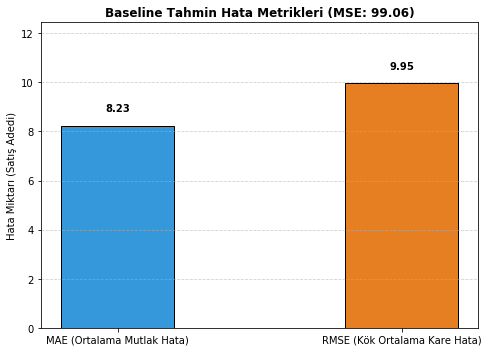

In [20]:
# Görselleştirme
import matplotlib.pyplot as plt
import seaborn as sns

# Metric Değerleri
metrics = ['MAE (Ortalama Mutlak Hata)', 'RMSE (Kök Ortalama Kare Hata)']
values = [baseline_mae, baseline_rmse]

plt.figure(figsize=(7, 5))
bars = plt.bar(metrics, values, color=['#3498db', '#e67e22'], width=0.4, edgecolor='black')

plt.title(f"Baseline Tahmin Hata Metrikleri (MSE: {baseline_mse:.2f})", fontsize=12, fontweight='bold')
plt.ylabel("Hata Miktarı (Satış Adedi)", fontsize=10)
plt.ylim(0, max(values) * 1.25)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Sütun üzerine değerleri yazdırma
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.5, f'{yval:.2f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

MAE: Mevcut demand forecast ürünlerin (Unit Sold) satış tahminini yaparken ortalama 8.23 birim  sapmaktadır. Yani tahminler gerçek satışın ortalama ~8 birim altında veya üstündedir

RMSE:  RMSE'nin (9.95) MAE'ye (8.23) oldukça yakın olması, mevcut sistemin çok büyük sürpriz hatalar yapmadığını, hataların belirli ve dengeli bir bantta seyrettiğini gösterir.

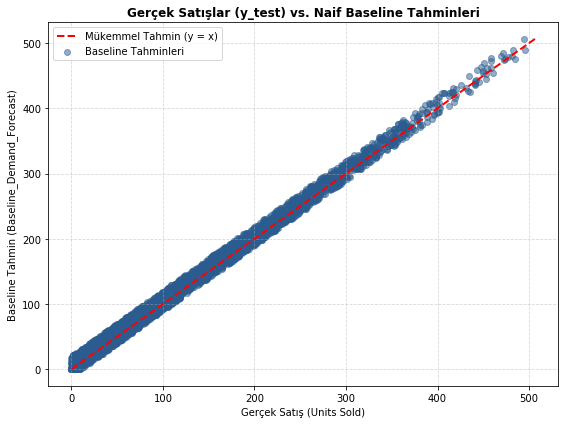

In [19]:
import numpy as np

plt.figure(figsize=(8, 6))

# Scatter plot
plt.scatter(y_test, baseline_pred, alpha=0.5, color='#2b5c8f', label='Baseline Tahminleri')

# Mükemmel tahmin çizgisi (y = x)
max_val = max(max(y_test), max(baseline_pred))
min_val = min(min(y_test), min(baseline_pred))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Mükemmel Tahmin (y = x)')

plt.title("Gerçek Satışlar (y_test) vs. Naif Baseline Tahminleri", fontsize=12, fontweight='bold')
plt.xlabel("Gerçek Satış (Units Sold)", fontsize=10)
plt.ylabel("Baseline Tahmin (Baseline_Demand_Forecast)", fontsize=10)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Benchmarkımız 
Veriseti sentetik olduğu için yani Unit Sold + Noise ile üretildiğinden tahmin değeri mükemmele çok yakın
Yani Naive_baseline çoook yüksek


# Model aşaması

Elinizdeki panel verisi (5 mağaza × 20 ürün = 100 farklı zaman serisi) ve dışsal değişkenler (stok, fiyat, hava durumu, lag/rolling özellikler) göz önüne alındığında izlediğiniz mantık ve çıkarımlar teorik açıdan son derece doğrudur.

1. Öncelikli Model Grubu: LightGBM ve XGBoost

Gelişmiş Ağaç Modelleri: 100 farklı zaman serisini tek bir model çatısı altında eğitmenize imkan tanır. Kategorik kimlikleri (Store ID, Product ID) ve türetilmiş zaman serisi özelliklerini (lag, rolling mean/std) en yüksek doğrula işleyen yapıdır.

Uygulama: Eğitimi LightGBM Regressor ile başlatın; category veri tipini native işlediği için oldukça hızlıdır. Ardından enable_categorical=True parametresiyle XGBoost Regressor eğitip metriklerini (MAE, RMSE) kıyaslayın.

2. Hiperparametre Optimizasyonu

En yüksek skoru veren gradient boosting modeli (genellikle LightGBM) üzerinde Optuna veya GridSearchCV ile parametre optimizasyonu yapın.

Zaman serisi yapısını korumak ve veri sızıntısını önlemek için cross-validation adımlarında mutlaka TimeSeriesSplit kullanın.

3. İstatistiksel Zaman Serisi Modellerine Yaklaşım (SARIMAX)

Tüm Veri Yerine Temsilci Benchmark: 100 ayrı SARIMAX modeli kurup yönetmek canlı ortam (production) servis mimarisi için verimsizdir.

Stratejik Kullanım: En çok satan 1 temsilci Mağaza-Ürün çifti (örneğin S001 - P0001) seçerek üzerinde SARIMAX eğitin.

Proje Hikayesi: Sunum veya raporunuzda "Mevsimselliği dikkate alan geleneksel SARIMAX modeli dışsal değişkenlerin karmaşık etkilerini tolere edemezken, geliştirdiğimiz LightGBM/XGBoost modeli hatayı %X oranında düşürmüştür" kıyaslamasını yapın.

In [31]:
X_train.dtypes

Store ID                   category
Product ID                 category
Inventory Level               int64
Units Ordered                 int64
Price                       float64
Discount                      int64
Holiday/Promotion             int64
Year                          int64
Month                         int64
Day                           int64
DayOfWeek                     int64
NET_PRICE                   float64
Price_Diff                  float64
Price_Ratio                 float64
units_sold_lag_1            float64
units_sold_lag_2            float64
units_sold_lag_3            float64
units_sold_lag_7            float64
units_sold_lag_14           float64
units_sold_lag_30           float64
units_sold_lag_365          float64
sales_roll_mean_7           float64
sales_roll_mean_30          float64
Category_Electronics          uint8
Category_Furniture            uint8
Category_Groceries            uint8
Category_Toys                 uint8
Region_North                

In [34]:
import pandas as pd
from xgboost import XGBRegressor
# =========================================================
# 1. Categorical features
# =========================================================

cat_features = ['Store ID', 'Product ID']


# =========================================================
# 2. Train / Validation / Test'te category dtype ayarla
# =========================================================

for col in cat_features:

    # Train'deki kategorileri belirle
    X_train[col] = X_train[col].astype("category")

    categories = X_train[col].cat.categories

    # Validation ve test'te train kategorilerini kullan
    X_val[col] = pd.Categorical(
        X_val[col],
        categories=categories
    )

    X_test[col] = pd.Categorical(
        X_test[col],
        categories=categories
    )


# =========================================================
# 3. Kontrol
# =========================================================

print("Train categorical features:")
print(X_train[cat_features].dtypes)

print("\nValidation categorical features:")
print(X_val[cat_features].dtypes)

print("\nTest categorical features:")
print(X_test[cat_features].dtypes)


# =========================================================
# 4. XGBoost Model
# =========================================================

xgb_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,

    objective="reg:squarederror",

    # Native categorical support
    enable_categorical=True,

    # Categorical data ile uyumlu
    tree_method="hist"
)


# =========================================================
# 5. Modeli eğit
# =========================================================

xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

Train categorical features:
Store ID      category
Product ID    category
dtype: object

Validation categorical features:
Store ID      category
Product ID    category
dtype: object

Test categorical features:
Store ID      category
Product ID    category
dtype: object


ValueError: Experimental support for categorical data is not implemented for current tree method yet.